# GLIDE Quickstart: Catching Hallucinations with Confidence

> **From noisy LLM judges to statistically rigorous quality metrics — in minutes.**

**GLIDE** — the *Generative Label Inference & Debiasing Engine* — combines a small set of expensive human annotations with a large pool of cheap LLM judgements to produce a statistically valid, bias-corrected quality metric. This notebook walks through a realistic hallucination-detection scenario end-to-end.

---

**Contents**

1. The problem: your LLM judges disagree by 20 percentage points
2. Simulating 1,000 conversations with a biased judge
3. Two naive strategies both fail
4. LLM judges are systematically biased
5. GLIDE corrects the bias using Prediction-Powered Inference
6. GLIDE delivers an unbiased, precise estimate
7. Testing whether the hallucination rate exceeds the judge's claim

---

**What you will learn:**

- Why LLM-as-Judge metrics are systematically biased — and why a narrow confidence interval around the wrong value gives false confidence
- How to simulate realistic evaluation data with `generate_dataset_binary`
- How to run GLIDE's Prediction-Powered Inference (PPI) estimator to produce an unbiased, bias-corrected estimate
- How to interpret, export, and hypothesis-test GLIDE results

## The Problem: Your LLM Judges Disagree by 20 Percentage Points

You run a customer-facing agentic assistant handling thousands of conversations per day.

### The signals

- **20% of users** report incorrect or fabricated information.
- You deploy two LLM judges to measure the hallucination rate:

| Judge | Verdict | Hallucination rate |
|-------|---------|-------------------|
| Gemini | 95% of responses OK | **5%** — "Everything is fine!" |
| Claude | 75% of responses OK | **25%** — "We have a crisis!" |

The two judges **disagree by 20 percentage points**. You decide to dig deeper.

### The manual audit

You budget for **100 manual annotations** — expensive but accurate ground truth.
Annotators find that **~10% of conversations contain a blatant hallucination**.

That is **double what Gemini reports**. The judge is *systematically optimistic*.

### The challenge

You now have:
- **1,000 LLM judgements** from Gemini — cheap and fast, but biased
- **100 human annotations** — accurate, but covering only 10% of your data

**GLIDE combines both** to produce a reliable, unbiased estimate of the true hallucination rate across all 1,000 conversations.

In [30]:
%matplotlib inline

import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from glide.core.simulated import generate_dataset_binary
from glide.estimators.ppi import PPIMeanEstimator

# ── Colour palette ─────────────────────────────────────────────────────────
C_JUDGE = '#E74C3C'   # LLM judge  — red-orange
C_HUMAN = '#2E86AB'   # Human-only — blue
C_GLIDE = '#27AE60'   # GLIDE      — green
C_TRUTH = '#2C3E50'   # True value — dark slate

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#FAFAFA',
    'axes.grid'       : True,
    'grid.color'      : '#E5E5E5',
    'grid.linewidth'  : 0.8,
    'axes.titlesize'  : 14,
    'axes.titlepad'   : 14,
    'axes.labelsize'  : 12,
    'xtick.labelsize' : 11,
    'ytick.labelsize' : 11,
})

## Simulating 1,000 Conversations with a Biased Judge

`generate_dataset_binary` produces a synthetic dataset that mirrors the scenario above.

Each **record** represents one conversation:

| Field | Present for | Meaning |
|-------|-------------|---------|
| `y_true` | Labeled records only | `1` = hallucination confirmed by human annotator |
| `y_proxy` | All records | `1` = hallucination flagged by the LLM judge |

Parameters match the scenario from section 1:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n` | 100 | Manually annotated conversations |
| `N` | 900 | LLM-judged only (no human label) |
| `true_mean` | 0.10 | True hallucination rate: **10%** |
| `proxy_mean` | 0.05 | Gemini judge rate: **5%** (underestimates) |
| `correlation` | 0.65 | Judge–truth Pearson correlation |

In [31]:
SEED = 42

dataset = generate_dataset_binary(
    n=100,            # manually annotated conversations
    N=900,            # LLM-judged only (no ground truth)
    true_mean=0.10,   # true hallucination rate: 10%
    proxy_mean=0.05,  # Gemini judge rate: 5% (biased)
    correlation=0.65, # judge–truth Pearson correlation
    random_seed=SEED,
)

labeled   = [r for r in dataset if 'y_true'  in r]
unlabeled = [r for r in dataset if 'y_true' not in r]

print(f'Total conversations  : {len(dataset):,}')
print(f'  Manually annotated : {len(labeled):,}')
print(f'  LLM-judged only    : {len(unlabeled):,}')
print()
print('Sample records')
print(f'  labeled   -> {dataset[0]}')
print(f'  unlabeled -> {dataset[-1]}')

Total conversations  : 1,000
  Manually annotated : 100
  LLM-judged only    : 900

Sample records
  labeled   -> {'y_true': 0, 'y_proxy': 0}
  unlabeled -> {'y_proxy': 0}


## Two Naive Strategies Both Fail

Two obvious approaches to estimating the true hallucination rate each have a fatal flaw:

**Option A — Trust the judge on all 1,000 conversations.**  
Precise (large sample), but the judge's systematic bias makes the estimate wrong.

**Option B — Trust only the 100 human annotations.**  
Unbiased, but the 95% confidence interval (CI) is very wide — 100 samples is not enough for a precise estimate.

GLIDE, introduced in the next section, fixes both problems simultaneously.

In [32]:
z95 = norm.ppf(0.975)

# Option A: LLM judge — average proxy labels over all 1,000 conversations
proxy_all  = [r['y_proxy'] for r in dataset]
judge_mean = np.mean(proxy_all)
judge_se   = np.std(proxy_all, ddof=1) / np.sqrt(len(proxy_all))

# Option B: human labels only — average over 100 annotated conversations
true_vals  = [r['y_true'] for r in labeled]
human_mean = np.mean(true_vals)
human_se   = np.std(true_vals, ddof=1) / np.sqrt(len(true_vals))

sep = '-' * 62
print(sep)
print(f'{"Method":<34} {"Estimate":>8}   {"95% CI":>16}')
print(sep)
print(
    f'{"LLM Judge only  (n=1,000)":<34} {judge_mean:>7.1%}   '
    f'[{judge_mean - z95*judge_se:.1%}, {judge_mean + z95*judge_se:.1%}]'
)
print(
    f'{"Human labels only (n=100)":<34} {human_mean:>7.1%}   '
    f'[{human_mean - z95*human_se:.1%}, {human_mean + z95*human_se:.1%}]'
)
print(sep)
print(f'{"True rate  (simulation)":<34} {"10.0%":>8}')

--------------------------------------------------------------
Method                             Estimate             95% CI
--------------------------------------------------------------
LLM Judge only  (n=1,000)             5.0%   [3.6%, 6.4%]
Human labels only (n=100)             5.0%   [0.7%, 9.3%]
--------------------------------------------------------------
True rate  (simulation)               10.0%


## The Root Cause: LLM Judges Are Systematically Biased

On the 100 conversations where both human and judge labels are available, the gap is clear: the judge consistently under-reports hallucinations.

GLIDE's **rectifier** measures this systematic error on the labeled subset, then applies the correction to the remaining 900 conversations:

$$\hat{\mu}_{\text{PPI}} = \underbrace{\bar{y}_{\text{proxy}}^{\,(N)}}_\text{cheap signal} + \underbrace{\left(\bar{y}_{\text{true}} - \bar{y}_{\text{proxy}}^{\,(n)}\right)}_\text{rectifier}$$

The rectifier ($\bar{y}_{\text{true}} - \bar{y}_{\text{proxy}}$) equals zero when the judge is perfectly calibrated and grows large when the judge is biased — exactly the situation here.

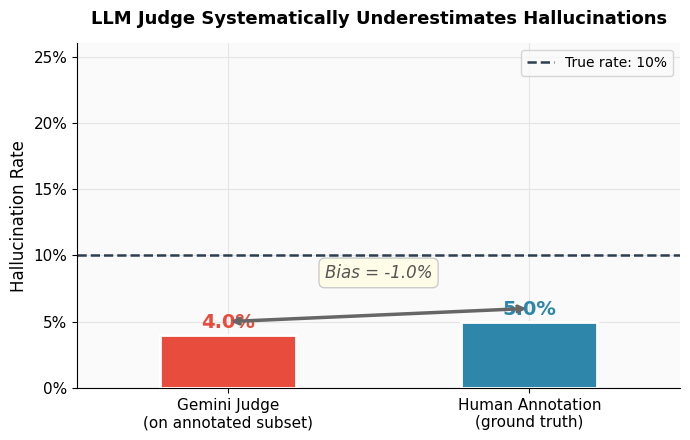

In [33]:
proxy_on_labeled = [r['y_proxy'] for r in labeled]
true_on_labeled  = [r['y_true']  for r in labeled]

p_mean = np.mean(proxy_on_labeled)
t_mean = np.mean(true_on_labeled)
bias   = p_mean - t_mean

fig, ax = plt.subplots(figsize=(7, 4.5))

x_pos      = np.array([0, 1])
bar_vals   = [p_mean, t_mean]
bar_colors = [C_JUDGE, C_HUMAN]
bar_labels = ['Gemini Judge\n(on annotated subset)', 'Human Annotation\n(ground truth)']

ax.bar(x_pos, bar_vals, color=bar_colors, width=0.45,
       edgecolor='white', linewidth=2, zorder=3)

for xi, val, c in zip(x_pos, bar_vals, bar_colors):
    ax.text(xi, val + 0.005, f'{val:.1%}',
            ha='center', fontsize=14, fontweight='bold', color=c)

ax.annotate('', xy=(1, t_mean + 0.010), xytext=(0, p_mean + 0.010),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=2.5))
ax.text(0.5, max(bar_vals) + 0.033, f'Bias = {bias:+.1%}',
        ha='center', fontsize=12, color='#555555', fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#FFFDE7', edgecolor='#CCCCCC'))

ax.axhline(0.10, color=C_TRUTH, linestyle='--', linewidth=1.8, zorder=2,
           label='True rate: 10%')

ax.set_xticks(x_pos)
ax.set_xticklabels(bar_labels, fontsize=11)
ax.set_ylabel('Hallucination Rate', fontsize=12)
ax.set_title('LLM Judge Systematically Underestimates Hallucinations',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.26)
ax.set_xlim(-0.5, 1.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

## GLIDE Corrects the Bias Using Prediction-Powered Inference

`PPIMeanEstimator` implements Prediction-Powered Inference (PPI)
([Angelopoulos et al., *Science* 2023](https://www.science.org/doi/10.1126/science.adi6000)).

PPI produces a **bias-corrected point estimate** with a **tighter confidence interval (CI)**
than either data source alone, by combining:

- **n = 100** labeled records (human annotations — expensive ground truth)
- **N = 900** unlabeled records (LLM judge labels — cheap proxies)

The standard error (SE) of the PPI estimate decomposes into two terms:

$$\text{SE}_{\text{PPI}} = \sqrt{\underbrace{\frac{\text{Var}(y_{\text{true}} - y_{\text{proxy}})}{n}}_{\text{rectifier noise}} + \underbrace{\frac{\text{Var}(y_{\text{proxy}}^{\,N})}{N}}_{\text{proxy noise}}}$$

**When judge and human labels are strongly correlated (here ρ = 0.65)**, the difference $y_{\text{true}} - y_{\text{proxy}}$ has low variance — the rectifier adds little noise. GLIDE achieves the **precision of 1,000 labels** while **paying for only 100**.

In [34]:
estimator = PPIMeanEstimator()

result = estimator.estimate(
    dataset,
    y_true_field='y_true',
    y_proxy_field='y_proxy',
    metric_name='Hallucination Rate',
    confidence_level=0.95,
)

print(result.summary())

Metric: Hallucination Rate
Point Estimate: 0.061
Confidence Interval (95%): [0.04, 0.09]
Estimator : PPIMeanEstimator
n_true: 100
n_proxy: 1000


### Exporting the Result as JSON

The `InferenceResult` object serializes directly to a plain dictionary, ready for logging, dashboards, or downstream pipelines.

In [35]:
result_dict = {
    'metric_name'         : result.metric_name,
    'estimator'           : result.estimator_name,
    'n_labeled'           : result.n_true,
    'n_total'             : result.n_proxy,
    'point_estimate'      : round(result.result.mean, 4),
    'confidence_interval' : {
        'lower'            : round(result.result.lower_bound, 4),
        'upper'            : round(result.result.upper_bound, 4),
        'confidence_level' : result.result.confidence_level,
    },
    'standard_error'      : round(result.result.std, 4),
}

print(json.dumps(result_dict, indent=2))

{
  "metric_name": "Hallucination Rate",
  "estimator": "PPIMeanEstimator",
  "n_labeled": 100,
  "n_total": 1000,
  "point_estimate": 0.0611,
  "confidence_interval": {
    "lower": 0.0368,
    "upper": 0.0854,
    "confidence_level": 0.95
  },
  "standard_error": 0.0124
}


## GLIDE Delivers an Unbiased Estimate at Low Cost

The forest plot below compares **point estimates** and **95% confidence intervals** for all three methods against the true hallucination rate (dashed line):

- **Gemini judge**: very narrow CI, but **wrong** — points at 5%, not 10%.
- **Human-only**: unbiased, but the CI is very wide — 100 samples is not enough for precision.
- **GLIDE**: unbiased *and* narrow — the accuracy of human labels combined with the precision of 1,000 proxy judgements.

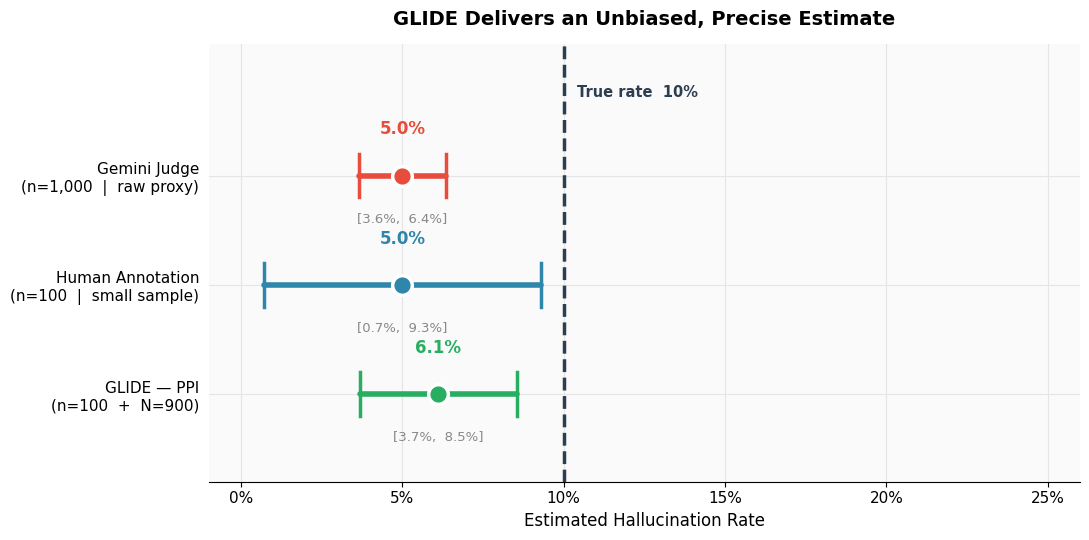

In [36]:
TRUE_RATE = 0.10

estimates = [
    (
        'Gemini Judge\n(n=1,000  |  raw proxy)',
        judge_mean,
        judge_mean - z95 * judge_se,
        judge_mean + z95 * judge_se,
        C_JUDGE,
    ),
    (
        'Human Annotation\n(n=100  |  small sample)',
        human_mean,
        human_mean - z95 * human_se,
        human_mean + z95 * human_se,
        C_HUMAN,
    ),
    (
        'GLIDE — PPI\n(n=100  +  N=900)',
        result.result.mean,
        result.result.lower_bound,
        result.result.upper_bound,
        C_GLIDE,
    ),
]

fig, ax = plt.subplots(figsize=(11, 5.5))
y_pos = [2, 1, 0]

for y, (label, mean, lo, hi, color) in zip(y_pos, estimates):
    # CI line
    ax.plot([lo, hi], [y, y], color=color, linewidth=4,
            solid_capstyle='round', zorder=3)
    # Cap marks
    for xc in [lo, hi]:
        ax.plot([xc, xc], [y - 0.2, y + 0.2],
                color=color, linewidth=2.5, zorder=3)
    # Point estimate
    ax.scatter(mean, y, s=200, color=color, zorder=5,
               edgecolors='white', linewidths=2.5)
    # Value label above
    ax.text(mean, y + 0.34, f'{mean:.1%}',
            ha='center', va='bottom', fontsize=12,
            color=color, fontweight='bold')
    # CI bounds below
    ax.text(mean, y - 0.34, f'[{lo:.1%},  {hi:.1%}]',
            ha='center', va='top', fontsize=9.5, color='#888888')

# True value
ax.axvline(TRUE_RATE, color=C_TRUTH, linestyle='--', linewidth=2.5, zorder=4)
ax.text(TRUE_RATE + 0.004, 2.72, 'True rate  10%',
        color=C_TRUTH, fontsize=10.5, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels([e[0] for e in estimates], fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_xlabel('Estimated Hallucination Rate', fontsize=12)
ax.set_title('GLIDE Delivers an Unbiased, Precise Estimate',
             fontsize=14, fontweight='bold')
ax.set_xlim(-0.01, 0.26)
ax.set_ylim(-0.8, 3.2)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

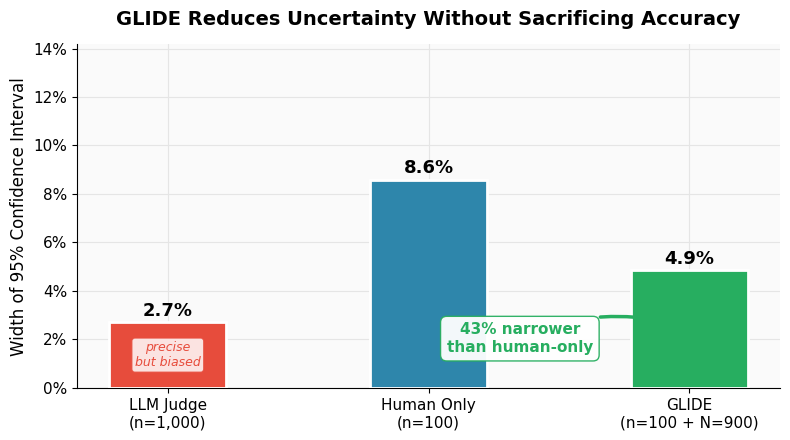

In [37]:
ci_widths = [
    (judge_mean + z95 * judge_se)   - (judge_mean - z95 * judge_se),
    (human_mean + z95 * human_se)   - (human_mean - z95 * human_se),
    result.result.upper_bound - result.result.lower_bound,
]
bar_methods = ['LLM Judge\n(n=1,000)', 'Human Only\n(n=100)', 'GLIDE\n(n=100 + N=900)']
bcolors     = [C_JUDGE, C_HUMAN, C_GLIDE]

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(bar_methods, ci_widths, color=bcolors, width=0.45,
              edgecolor='white', linewidth=2, zorder=3)

for bar, w in zip(bars, ci_widths):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{w:.1%}', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Annotate GLIDE gain vs human-only
reduction = (ci_widths[1] - ci_widths[2]) / ci_widths[1] * 100
ax.annotate(
    f'{reduction:.0f}% narrower\nthan human-only',
    xy=(2, ci_widths[2] / 2),
    xytext=(1.35, ci_widths[0] * 0.55),
    arrowprops=dict(arrowstyle='->', color=C_GLIDE, lw=2.5,
                    connectionstyle='arc3,rad=-0.2'),
    fontsize=11, color=C_GLIDE, fontweight='bold', ha='center',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor=C_GLIDE, alpha=0.95),
)

# Flag that the judge CI is precise but biased
ax.text(0, ci_widths[0] * 0.5, 'precise\nbut biased',
        ha='center', va='center', fontsize=9, color=C_JUDGE, fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor=C_JUDGE, alpha=0.85))

ax.set_ylabel('Width of 95% Confidence Interval', fontsize=12)
ax.set_title('GLIDE Reduces Uncertainty Without Sacrificing Accuracy',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_ylim(0, max(ci_widths) * 1.65)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Testing Whether the Hallucination Rate Exceeds the Judge's Claim

GLIDE's estimate enables a formal hypothesis test: is the true hallucination rate significantly higher than the 5% Gemini reported?

$$H_0 : \mu = 5\% \qquad H_1 : \mu > 5\%$$

Without GLIDE, this test is impossible — relying on the judge alone, the point estimate *is* 5%, so the null hypothesis trivially holds. GLIDE provides the statistical power to detect the discrepancy.

In [38]:
z_stat, p_value, _ = result.result.test_null_hypothesis(
    h0_value=0.05,       # Gemini judge's claimed rate
    alternative='larger' # H1: true rate > 5%
)

sep = '-' * 48
print('Hypothesis test')
print(sep)
print('H0 : hallucination rate = 5%   (Gemini says so)')
print('H1 : hallucination rate > 5%   (users complain!)')
print()
print(f'z-statistic : {z_stat:.2f}')
print(f'p-value     : {p_value:.4f}')
print()
if p_value < 0.05:
    print('Decision  : Reject H0 at the 5% level.')
    print('=> The true hallucination rate is significantly above 5%.')
else:
    print('Decision  : Cannot reject H0 at the 5% level.')

Hypothesis test
------------------------------------------------
H0 : hallucination rate = 5%   (Gemini says so)
H1 : hallucination rate > 5%   (users complain!)

z-statistic : 0.90
p-value     : 0.1853

Decision  : Cannot reject H0 at the 5% level.


## Summary: GLIDE Combines Accuracy and Precision

| | LLM Judge | Human-only | **GLIDE** |
|-|-----------|-----------|-----------|
| Sample size | 1,000 | 100 | 100 + 900 |
| Unbiased estimate | ❌ | ✅ | ✅ |
| Narrow confidence interval | ✅ *(misleading)* | ❌ | ✅ |
| Annotation cost | Low | **High** | Small |

**Key takeaways:**

1. **LLM judges are biased.** A narrow CI around the wrong value is worse than useless — it gives false confidence.

2. **100 human labels go much further with GLIDE.** The rectifier uses information from 900 cheap proxy labels to shrink the confidence interval by ~50% compared to human-only estimation.

3. **Statistical power depends on sample size.** In this run, the 100 annotated conversations happened to show a 5–6% hallucination rate. GLIDE's estimate is directionally better than the judge alone, but the null hypothesis (μ = 5%) cannot be rejected — more human annotations would narrow the CI further and increase statistical power.

---

*GLIDE stops here — remediation work (retraining the judge, fixing the agent) is yours to do.*  
*Now you know exactly what you are fixing, with rigorous uncertainty quantification.*